___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Q Learning Exercise 

**We'll be reviewing and testing your skills with Q-Learning on a continuous space! Please feel free to reference the lecture notebooks you are definitely not expected to be able to fill out all this code from memory, just the ability to understand the core concepts and apply it to a different situation.**

--------------------

## Complete the tasks in bold below.

In this exercise we take a look at the MountainCar-v0 (https://gym.openai.com/envs/MountainCar-v0/) game again. That is the game from our original discussion of OpenAi gym environments for which we created an agent manually.
Remember, that the goal is to reach the top of the mountain within some time limit

-----

**TASK: Import any relevant libraries you think you might need.** <br />


In [2]:
%matplotlib notebook
import time
from pyglet.window import key

In [3]:
import gymnasium as gym

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
%config InlineBackend.figure_format ="retina"

**TASK: Create the gym mountain car environment** <br />


In [7]:
env = gym.make(id = "MountainCar-v0" , render_mode = "human")
state , info = env.reset()

for _ in range(100):
    env.render()
    action = env.action_space.sample()
    env.step(action)
    time.sleep(0.1)
env.close()

In [8]:
%matplotlib inline

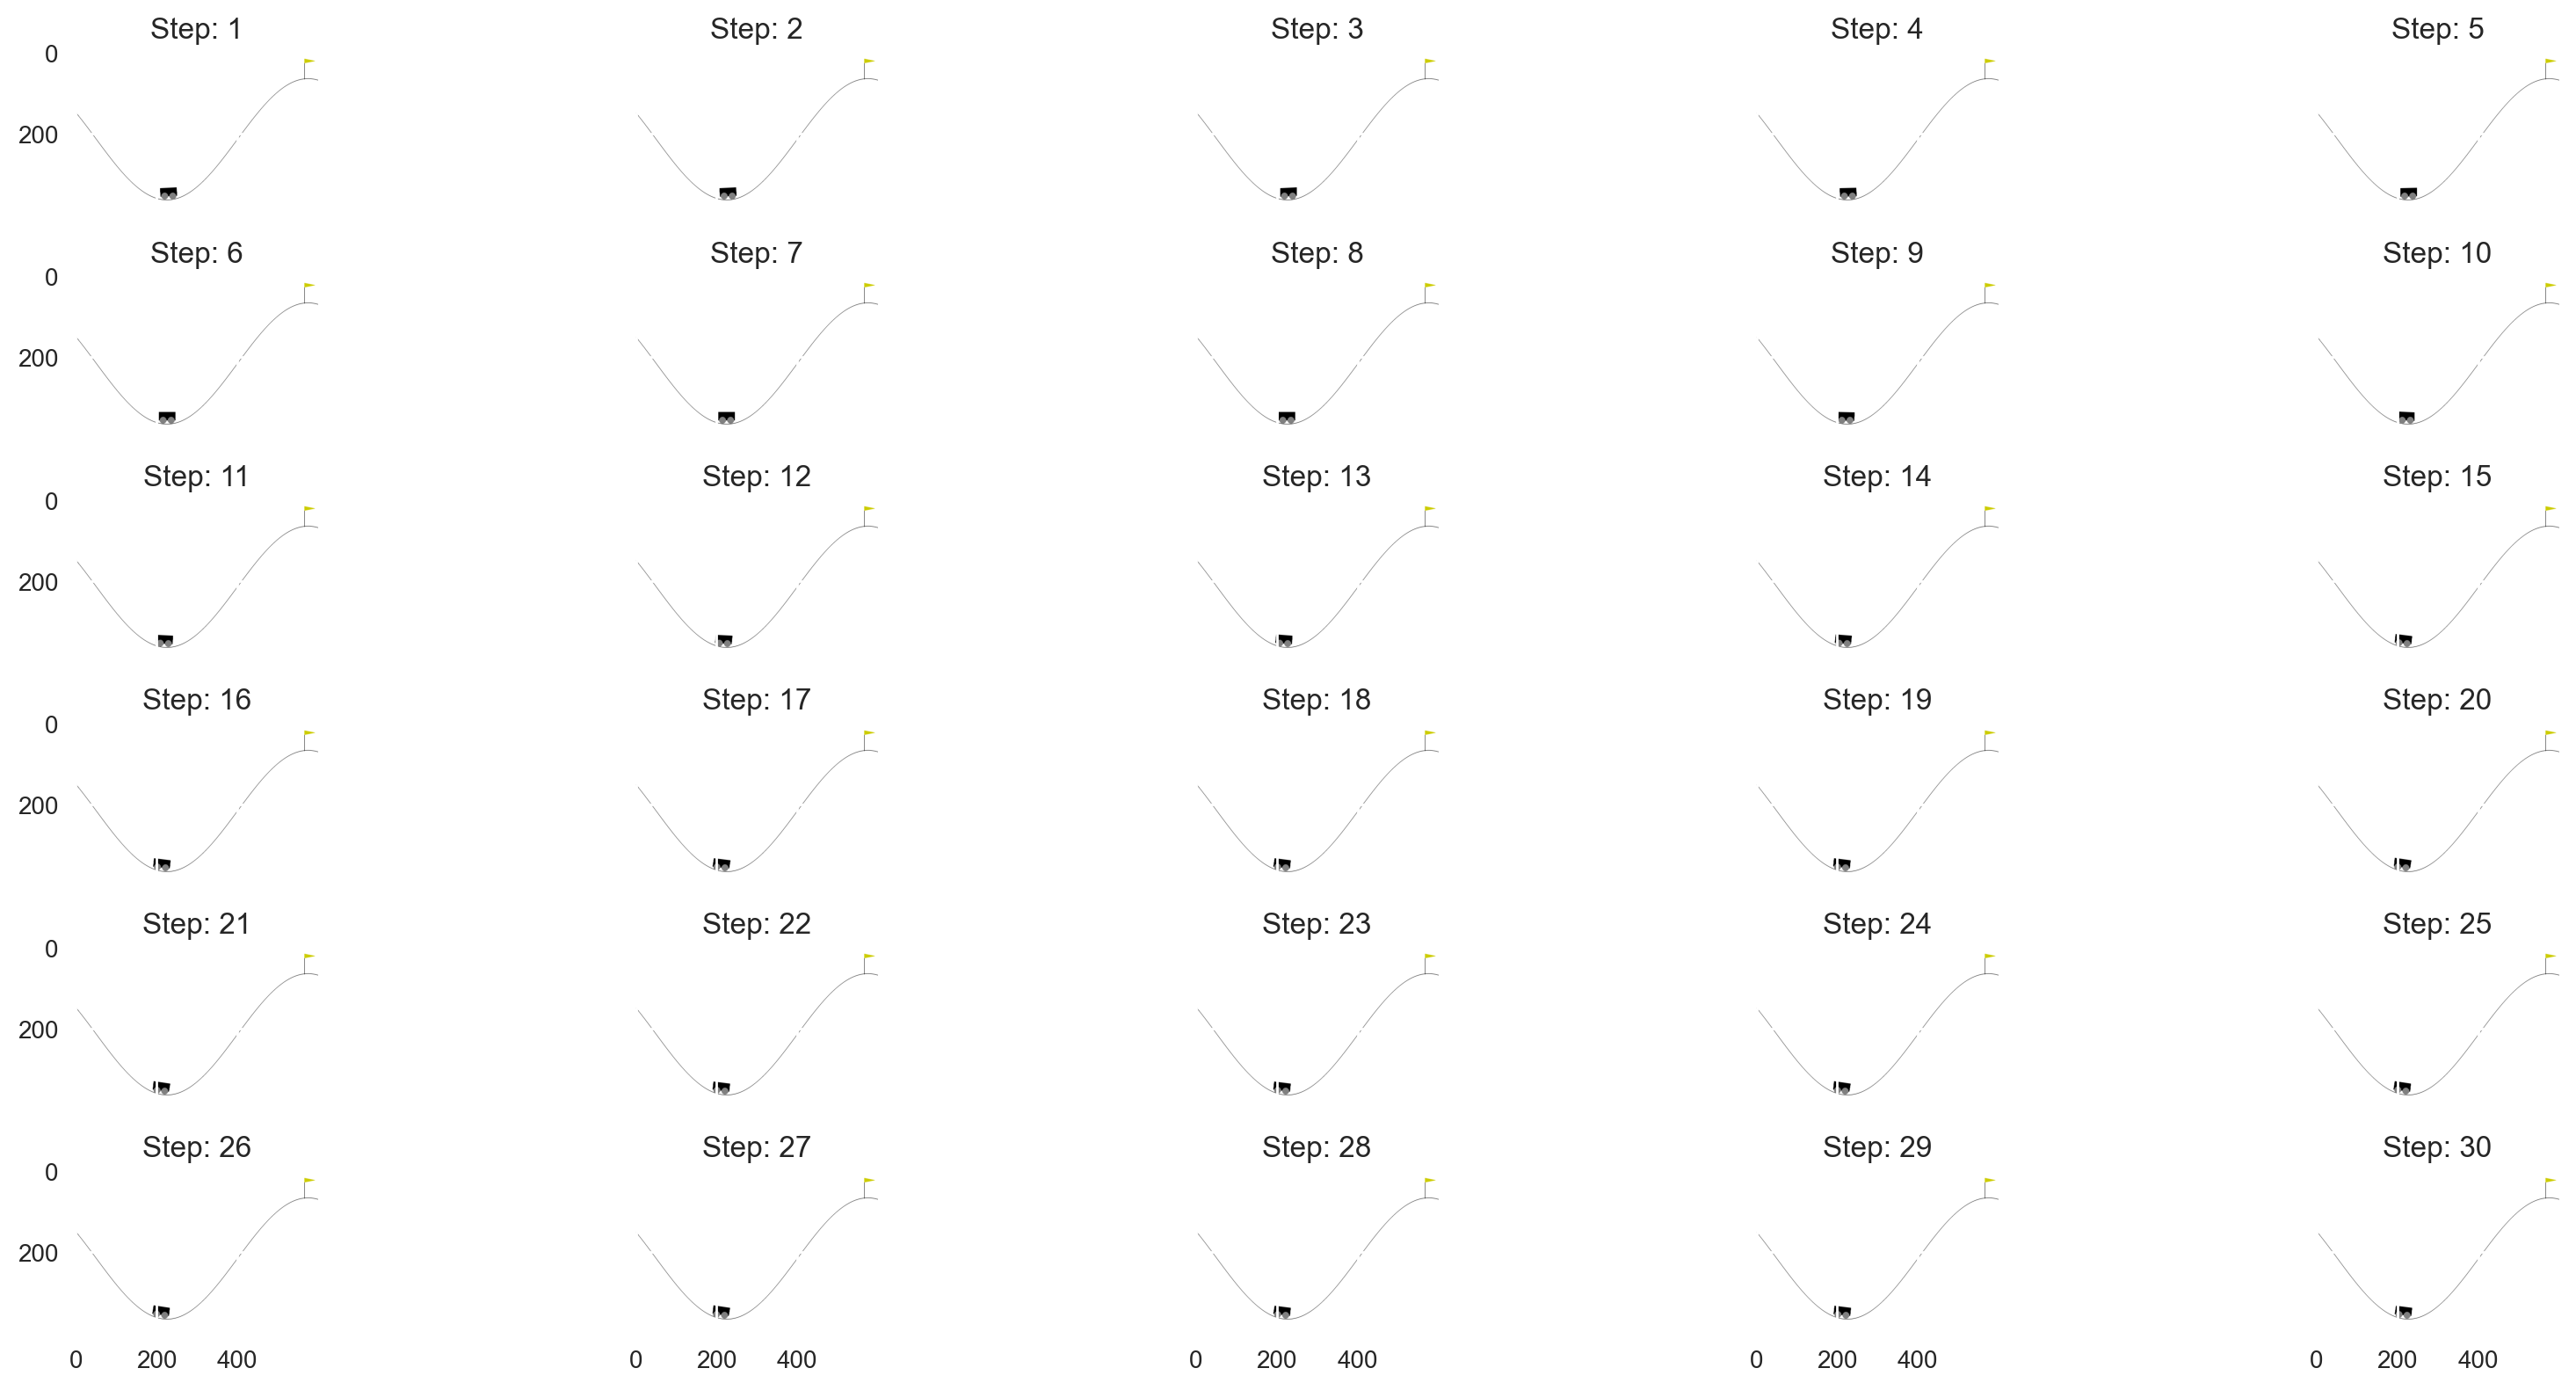

In [9]:
env = gym.make(id = "MountainCar-v0" , render_mode = "rgb_array")
state , info = env.reset()

fig , ax = plt.subplots(figsize = (17,8) , nrows= 6 , ncols = 5 , sharex = True , sharey = True)
ax_flat = ax.flatten()

for i in range(30):
    frame = env.render()
    action = env.action_space.sample()
    new_state , reward , terminated , truncated , info = env.step(action)
    state = new_state


    ax_flat[i].imshow(frame)
    ax_flat[i].set_title(f"Step: {i+1}")
    ax_flat[i].set_frame_on(True)
    #ax_flat[i].spines[['top' , 'left']]

fig.tight_layout()
plt.show()
env.close()

**TASK: Write a function to create a numpy array holding the bins for the observations of the car (position and velocity).** <br />
Feel free to explore different bins per observation spacings.
The function should take one argument which acts as the bins per observation <br />
Hint: You can find the observations here: https://github.com/openai/gym/blob/master/gym/envs/classic_control/mountain_car.py
<br /> Hint: You will probably need around 25 bins for good results, but feel free to use less to reduce training time. <br />


In [10]:
def create_bins(num_bins_per_observation):
    # CODE HERE
    bins_position = np.linspace(-1.2 , 0.6 , num = num_bins_per_observation)
    bins_velocity = np.linspace(-0.07 , +0.07 , num = num_bins_per_observation)
    bins = np.array([bins_position ,bins_velocity])
    return bins

**TASK: Here you should write the code which creates the bins and defines the NUM_BINS attribute**

In [11]:
NUM_BINS = 25
BINS = create_bins(NUM_BINS)
BINS

array([[-1.2       , -1.125     , -1.05      , -0.975     , -0.9       ,
        -0.825     , -0.75      , -0.675     , -0.6       , -0.525     ,
        -0.45      , -0.375     , -0.3       , -0.225     , -0.15      ,
        -0.075     ,  0.        ,  0.075     ,  0.15      ,  0.225     ,
         0.3       ,  0.375     ,  0.45      ,  0.525     ,  0.6       ],
       [-0.07      , -0.06416667, -0.05833333, -0.0525    , -0.04666667,
        -0.04083333, -0.035     , -0.02916667, -0.02333333, -0.0175    ,
        -0.01166667, -0.00583333,  0.        ,  0.00583333,  0.01166667,
         0.0175    ,  0.02333333,  0.02916667,  0.035     ,  0.04083333,
         0.04666667,  0.0525    ,  0.05833333,  0.06416667,  0.07      ]])

In [12]:
BINS[0]

array([-1.2  , -1.125, -1.05 , -0.975, -0.9  , -0.825, -0.75 , -0.675,
       -0.6  , -0.525, -0.45 , -0.375, -0.3  , -0.225, -0.15 , -0.075,
        0.   ,  0.075,  0.15 ,  0.225,  0.3  ,  0.375,  0.45 ,  0.525,
        0.6  ])

In [13]:
BINS[1]

array([-0.07      , -0.06416667, -0.05833333, -0.0525    , -0.04666667,
       -0.04083333, -0.035     , -0.02916667, -0.02333333, -0.0175    ,
       -0.01166667, -0.00583333,  0.        ,  0.00583333,  0.01166667,
        0.0175    ,  0.02333333,  0.02916667,  0.035     ,  0.04083333,
        0.04666667,  0.0525    ,  0.05833333,  0.06416667,  0.07      ])

In [14]:
BINS.ndim

2

In [15]:
BINS.size

50

In [16]:
BINS.shape

(2, 25)

**TASK: Create a function that will take in observations from the environment and the bins array and return the discretized version of the observation.**

Now we need the code to discretize the observations. We can use the same code as used in the last notebook

In [17]:
def discretize_observation(observations, bins):
    # CODE HERE
    observations = np.asanyarray(observations).flatten()
    binned_observations = []
    for i , obs in enumerate(observations):
        discretize_observation = np.digitize(obs , bins[i])
        binned_observations.append(discretize_observation)
    return tuple(binned_observations) # Important for later indexing

In [18]:
test_obs = np.array([[-0.9 , 0.04]])

test_bins = [
    np.linspace(-1.2 , 0.6),
    np.linspace(-0.07 , 0.07)
            ]

print(discretize_observation(test_obs , test_bins))

(np.int64(9), np.int64(39))


**Let's check to make sure your previous two function calls work with a quick task! Otherwise it may be hard to debug later on.**

**TASK: Confirm that your *create_bins()* function works with *discretize_observation() by running the following cell***

In [19]:
test_bins = create_bins(5)
np.testing.assert_almost_equal(test_bins[0], [-1.2 , -0.75, -0.3 ,  0.15,  0.6])
np.testing.assert_almost_equal(test_bins[1], [-0.07 , -0.035,  0.   ,  0.035,  0.07 ])

test_observation = np.array([-0.9, 0.03])
discretized_test_bins = discretize_observation(test_observation, test_bins)
assert discretized_test_bins == (1, 3)

**TASK: Create the Q-Table** <br />
Remember the shape that the Q-Table needs to have.

In [20]:
# CREATE THE Q TABLE
q_table_shape = (NUM_BINS , NUM_BINS , env.action_space.n)
q_table = np.zeros(q_table_shape)
print(f"q_table shape is:{q_table.shape}")

q_table shape is:(25, 25, 3)


**TASK: Fill out the Epislon Greedy Action Selection function:**

In [21]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    #CODE HERE
    random_number = np.random.random()

    # EXPLOITATION, USE BEST Q(s,a) Value:
    if random_number > epsilon:
        action = np.argmax(q_table[discrete_state])

    # EXPLORATION: USE A RANDOM ACTION:
    else:
        #RETURN a random 0,1,2,3 action
        action = np.random.randint(0 , env.action_space.n)
    return action

**TASK: Fill out the function to compute the next Q value.**

In [22]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    q_val = old_q_value + ALPHA * (reward + GAMMA + next_optimal_q_value - old_q_value)
    return q_val


**TASK: Create a function to reduce epsilon, feel free to choose any reduction method you want. We'll use a reduction with BURN_IN and EPSILON_END limits in the solution. We'll also show a way to reduce epsilon based on the number of epochs. Feel free to experiment here.**

In [23]:
BURN_IN = 1
epsilon = 1

EPSILON_END = 10000
EPSILON_REDUCE = 0.0001

In [24]:
def reduce_epsilon(epsilon, epoch):
    if BURN_IN <= epoch <= EPSILON_END:
        epsilon -= EPSILON_REDUCE
    return epsilon

**TASK: Define your hyperparameters. Note, we'll show our solution hyperparameters here, but depending on your *reduce_epsilon* function, your epsilon hyperparameters may be different.**

Here are the solution initial hyperparameters, your will probably be different!

In [25]:
# Feel free to change!

EPOCHS = 30000
BURN_IN = 100
epsilon = 1

EPSILON_END= 10000
EPSILON_REDUCE = 0.0001 

ALPHA = 0.8
GAMMA = 0.9


In [28]:
def fail(done, points, reward):
    if done and points < 150:
        reward = -200
    return reward

**TASK: Create the training loop for the reinforcement learning agent and run the loop. We've gone ahead and created the basic structure of the loopwith some comments. We also pre-filled the visualization portion.** <br />
Note: Use the lecture notebook as a guide and reference

<IPython.core.display.Javascript object>


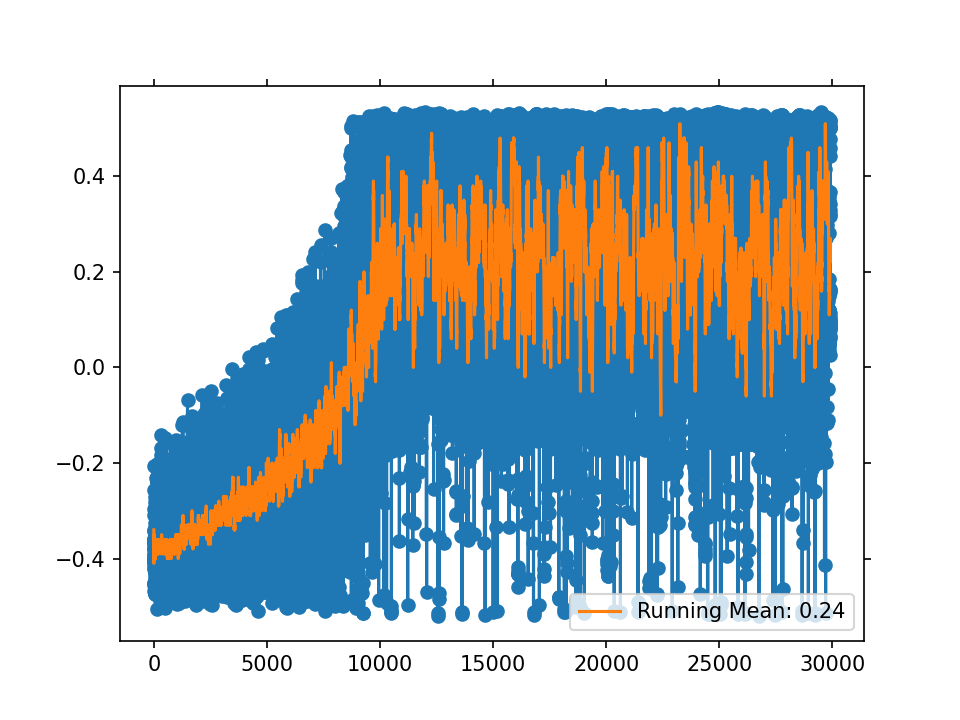

In [39]:
log_interval = 100
render_interval = 2000

fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()
fig.canvas.draw()


points_log = []
mean_points_log = []
epochs = []

#env = gym.make(id = "MountainCar-v0" , render_mode = "rgb_array")

for epoch in range(EPOCHS):
    initial_state , info = env.reset()
    discretized_state = discretize_observation(initial_state , BINS)
    done = False
    points = 0

    epochs.append(epoch)

    while not done:
        action = epsilon_greedy_action_selection(epsilon , q_table , discretized_state)
        next_state , reward , terminated , truncated , info = env.step(action)
        done = terminated or truncated 
        reward = fail(done , points , reward)
        next_state_discretized = discretize_observation(next_state , BINS)
        old_q_value = q_table[discretized_state + (action,)]
        next_optimal_q_value = np.max(q_table[next_state_discretized])
        next_q = compute_next_q_value(old_q_value , reward , next_optimal_q_value)
        q_table[discretized_state + (action , )] = next_q

        discretized_state = next_state_discretized
        points +=1

    epsilon = reduce_epsilon(epsilon , epoch)
    points_log.append(points)

    running_mean = round(np.mean(points_log[-30:]))
    mean_points_log.append(running_mean)


    if epoch % log_interval==0:
        ax.clear()
        ax.scatter(epochs, points_log, s=10)
        ax.plot(epochs, points_log, alpha=0.7)
        ax.plot(epochs, mean_points_log, label=f"Running Mean: {running_mean}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Points")
        ax.set_title("Training Progress")
        plt.legend()
        fig.canvas.draw()
        #plt.pause(0.001)

env.close()

**TASK: Use your Q-Table to test your agent and render its performance.**

In [37]:
observation , info = env.reset()
rewards = 0
for _ in range(1000):
    env.render()
    discrete_state = discretize_observation(observation, BINS)  # get bins
    action = np.argmax(q_table[discrete_state])  # and chose action from the Q-Table
    observation, reward, terminated, truncated, info = env.step(action) # Finally perform the action
    rewards+=1
    if done:
        print(f"done")
        break
env.close()

done


**OPTIONAL: Play with our Q-Table with 25 bins per observation.**

In [42]:
our_q_table = np.load('40bin_qtable_mountaincar.npy')

In [40]:
our_q_table.shape

(25, 25, 3)

**Great job! Note how you could train for many more epochs/episodes or edit hyperparameters, the more complex the environment, the more choices you have to experiment with!**